# 08 - RQ3: Which backbone wins?

> *Under an identical protocol, which backbone is better for which molecular
> property?*  Measured by: same-protocol MAE per property.

No measurement needed - this reads `history.json` at the epoch `train.py`
checkpointed, the same numbers behind the performance tables.

**How the margin is computed**

    margin_t = 100 * (MAE_GNN,t - MAE_UniMol,t) / MAE_GNN,t

Positive means Uni-Mol's error is *lower* by that fraction of the GNN's error.
+40% reads as "Uni-Mol's error is 40% smaller than the GNN's on this property".
The denominator is the GNN, so every property is on a comparable 0-100 scale
even though the raw MAEs span four orders of magnitude.

In [10]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, ".")
import numpy as np, matplotlib.pyplot as plt
import common as C
C.apply_style()

TAG     = "11task"     # "2task" or "11task"
COMPARE = "best"       # "best" = best MTL method per backbone,
                       # or a method name: "LS" | "PCGrad" | "AIM-Scalar" | "AIM-Matrix"
COMPARE = "AIM-Matrix"
SUB     = f"{TAG}/rq3"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Build the head-to-head

In [11]:
U = C.load_runs("Uni-Mol", TAG)
G = C.load_runs("GNN", TAG)
tasks = U["tasks"]
meths = [m for m in C.METHODS if m in U["mtl"] and m in G["mtl"]]

def mtl_mae(d, t):
    """MAE under the chosen comparison rule."""
    if COMPARE == "best":
        return min(d["mtl"][m][t] for m in meths)
    return d["mtl"][COMPARE][t]

rows = [["property", "unit", "Uni-Mol STL", "GNN STL", "STL",
         "Uni-Mol MTL", "GNN MTL", "MTL", "margin %"]]
margin = {}
for t in tasks:
    su, sg = U["stl"].get(t, np.nan), G["stl"].get(t, np.nan)
    bu, bg = mtl_mae(U, t), mtl_mae(G, t)
    # margin: how much lower Uni-Mol's error is, as a fraction of the GNN's
    margin[t] = 100.0 * (bg - bu) / bg
    rows.append([t, C.TASK_UNITS.get(t, ""),
                 f"{su:.4f}", f"{sg:.4f}",
                 ("Uni-Mol" if su < sg else "GNN") + "*",
                 f"{bu:.4f}", f"{bg:.4f}",
                 ("Uni-Mol" if bu < bg else "GNN") + "*",
                 f"{margin[t]:+.0f}"])

wins_u = sum(1 for t in tasks if margin[t] > 0)
print(f"{TAG} | comparison: {COMPARE} | methods available: {', '.join(meths)}")
print(f"Uni-Mol wins {wins_u}/{len(tasks)} properties under MTL; "
      f"GNN wins {len(tasks)-wins_u}/{len(tasks)}")
stl_u = sum(1 for t in tasks if U["stl"].get(t, np.inf) < G["stl"].get(t, np.inf))
print(f"Under STL it is Uni-Mol {stl_u}/{len(tasks)}, GNN {len(tasks)-stl_u}/{len(tasks)} "
      "-- note where the verdict flips")

11task | comparison: AIM-Matrix | methods available: LS, PCGrad, AIM-Scalar, AIM-Matrix
Uni-Mol wins 10/11 properties under MTL; GNN wins 1/11
Under STL it is Uni-Mol 6/11, GNN 5/11 -- note where the verdict flips


## Table

saved E:\Projects\aim_mtl\notebooks\figures\11task\rq3\rq3_table_11task.png


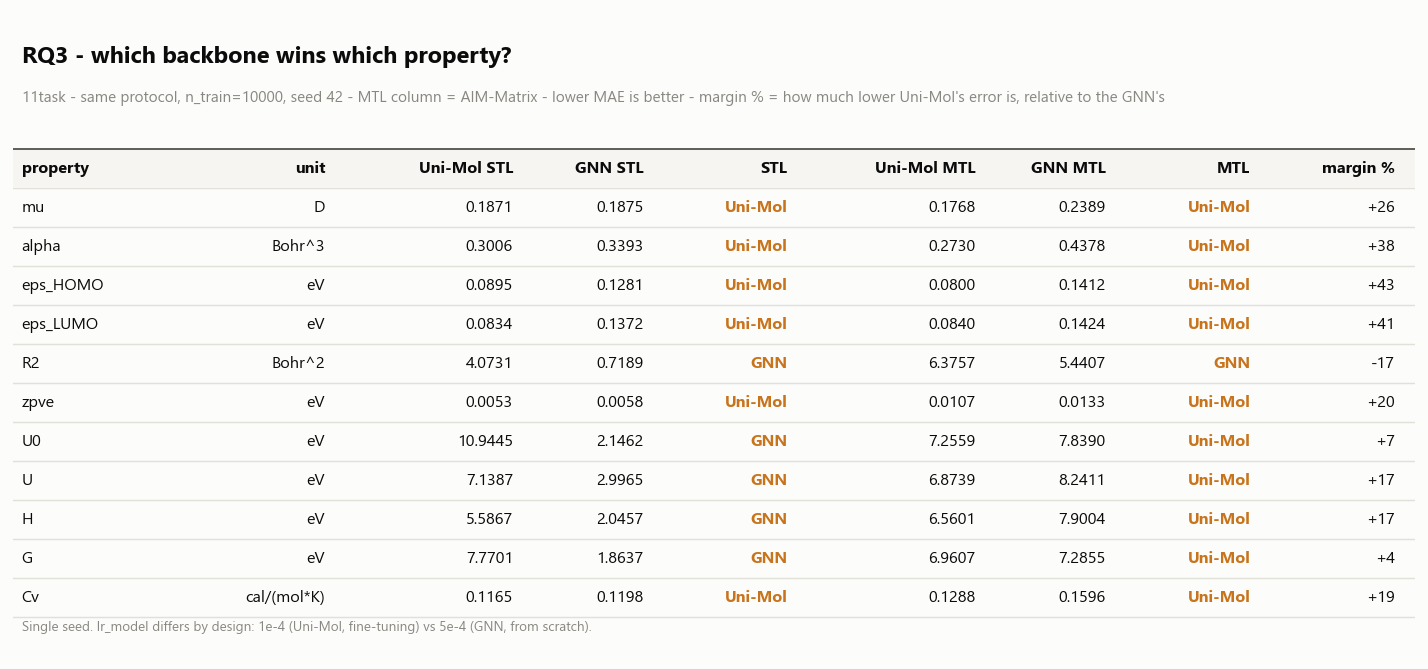

In [12]:

fig = C.table_png(
    rows,
    "RQ3 - which backbone wins which property?",
    f"{TAG} - same protocol, n_train={C.N_TRAIN}, seed {C.SEED} - "
    f"MTL column = {'best of ' + ', '.join(meths) if COMPARE == 'best' else COMPARE} - "
    "lower MAE is better - margin % = how much lower Uni-Mol's error is, "
    "relative to the GNN's",
    note="Single seed. lr_model differs by design: 1e-4 (Uni-Mol, fine-tuning) "
         "vs 5e-4 (GNN, from scratch).",
    fname=f"rq3_table_{TAG}", subdir=SUB)
plt.show()

## Figure - the margin per property

saved E:\Projects\aim_mtl\notebooks\figures\11task\rq3\rq3_margin_11task.png


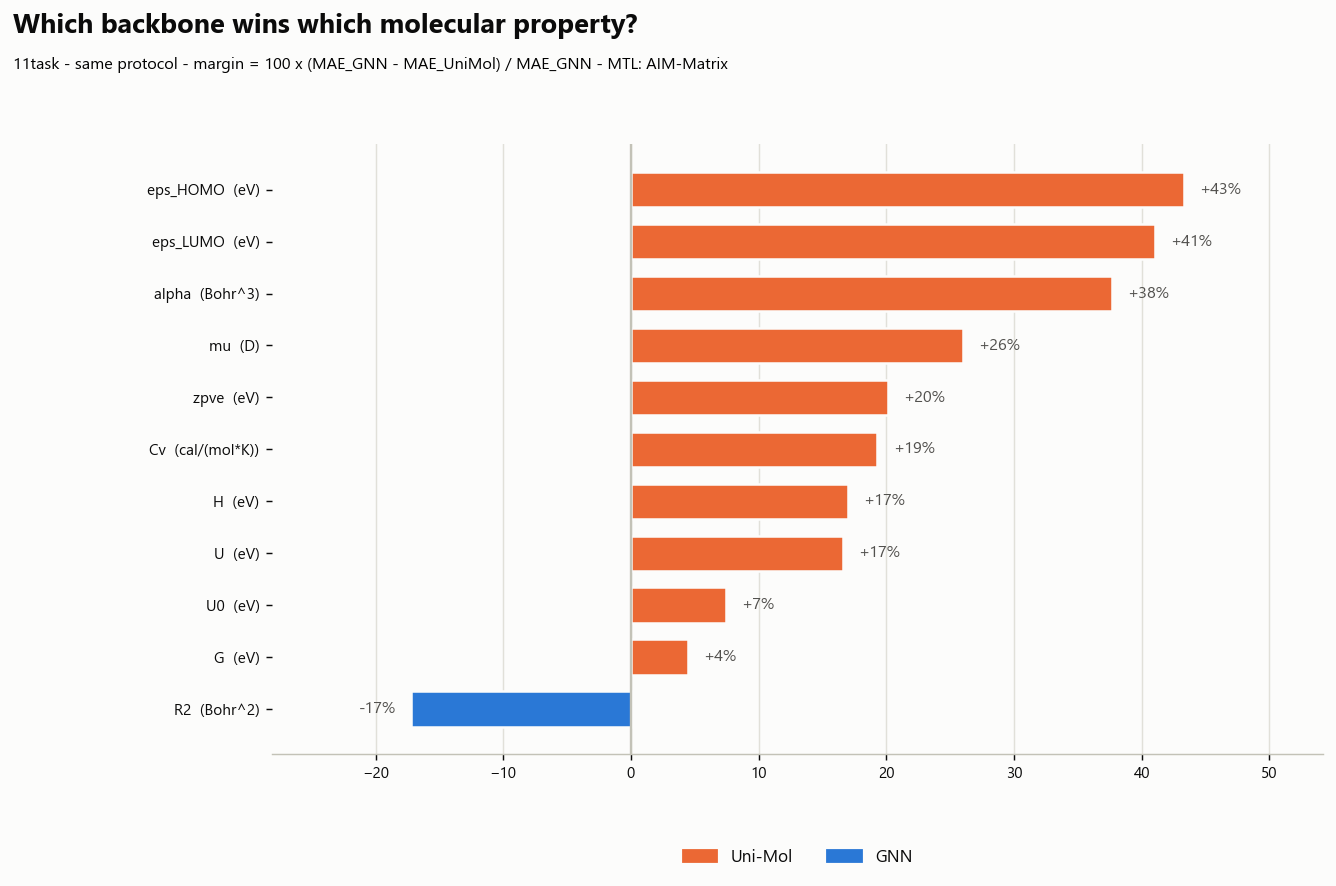

In [13]:
GNN, UNI = "#2a78d6", "#eb6834"
C.BACKBONE_COLOUR["GNN"] = GNN
C.BACKBONE_COLOUR["Uni-Mol"] = UNI

order = sorted(tasks, key=lambda t: margin[t])
vals = [margin[t] for t in order]
cols = [C.BACKBONE_COLOUR["Uni-Mol"] if v > 0 else C.BACKBONE_COLOUR["GNN"]
        for v in vals]

fig, ax = plt.subplots(figsize=(10.5, 0.42 * len(order) + 2.6))
y = np.arange(len(order))
ax.barh(y, vals, .68, color=cols, edgecolor=C.SURFACE, linewidth=1.4, zorder=3)
for yi, v, t in zip(y, vals, order):
    ax.text(v + (1.2 if v >= 0 else -1.2), yi, f"{v:+.0f}%",
            va="center", ha="left" if v >= 0 else "right",
            fontsize=9, color=C.SECONDARY)
ax.axvline(0, color=C.AXIS, lw=1.3, zorder=4)
ax.set_yticks(y, [f"{t}  ({C.TASK_UNITS.get(t,'')})" for t in order])
#ax.set_xlabel("Uni-Mol error lower  ->                <-  GNN error lower")
ax.margins(x=.18)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.grid(True, axis="x", zorder=0); ax.set_axisbelow(True)

h = [plt.Rectangle((0, 0), 1, 1, color=C.BACKBONE_COLOUR[b])
     for b in ("Uni-Mol", "GNN")]
ax.legend(h, ["Uni-Mol", "GNN"], loc="upper center",
          bbox_to_anchor=(.5, -.13), ncol=2)

fig.suptitle("Which backbone wins which molecular property?", x=.01, y=.99,
             ha="left", fontsize=15, fontweight="bold", color=C.INK)
fig.text(.01, .93,
         f"{TAG} - same protocol - margin = 100 x (MAE_GNN - MAE_UniMol) / MAE_GNN - "
         f"MTL: {'best method per backbone' if COMPARE == 'best' else COMPARE}",
         fontsize=9, color="black", ha="left")
fig.subplots_adjust(left=.20, right=.97, top=.85, bottom=.20)
C.save(fig, f"rq3_margin_{TAG}", SUB)
plt.show()

## Bar plots - absolute MAE, Uni-Mol vs GNN side by side

Two figures: one for the single-task baselines, one for multi-task.
The y-axis is log by default because the raw MAEs run from 0.005 eV
(zpve) to ~11 eV (U0) - on a linear axis the small properties vanish.
Set `LOG = False` in the cell below if you would rather have a linear
axis, and read the values off the bar labels.

saved E:\Projects\aim_mtl\notebooks\figures\11task\rq3\rq3_bars_stl_11task.png


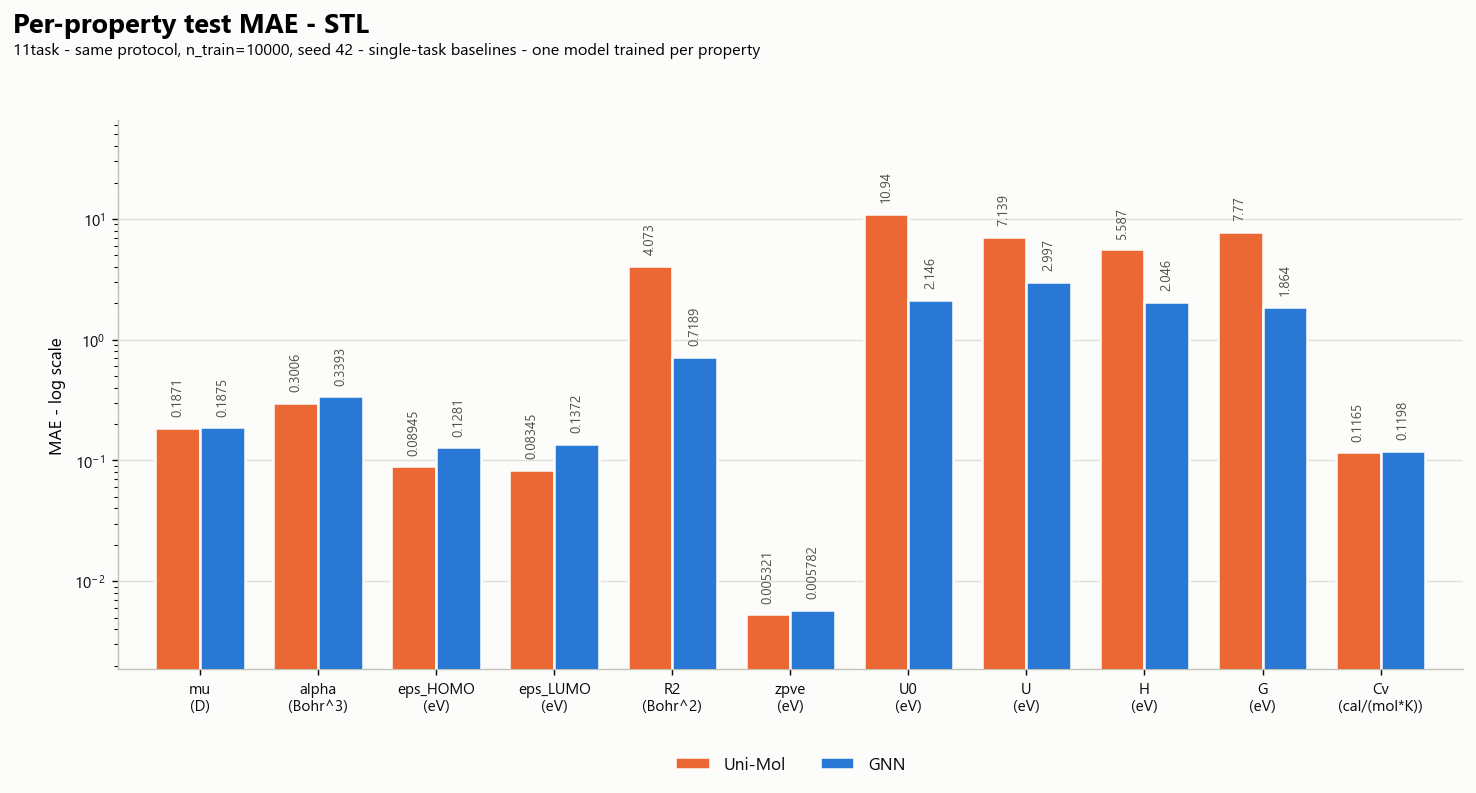

saved E:\Projects\aim_mtl\notebooks\figures\11task\rq3\rq3_bars_mtl_11task.png


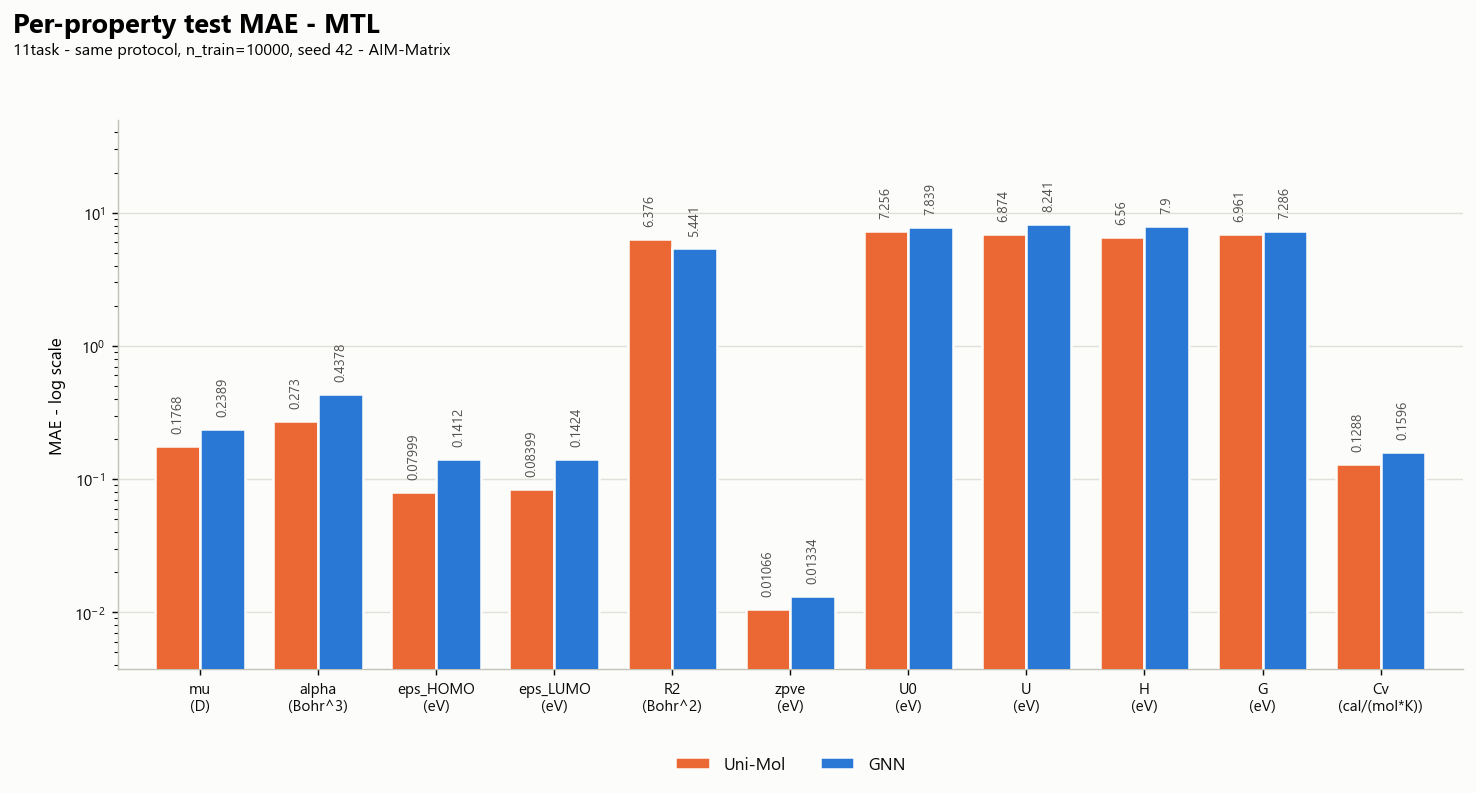

In [14]:
LOG = True          # MAEs span four orders of magnitude; False = linear axis

def grouped_bars(regime):
    """Side-by-side Uni-Mol vs GNN test MAE, one bar pair per property."""
    if regime == "STL":
        uu = {t: U["stl"][t] for t in tasks}
        gg = {t: G["stl"][t] for t in tasks}
        sub = "single-task baselines - one model trained per property"
    else:
        uu = {t: mtl_mae(U, t) for t in tasks}
        gg = {t: mtl_mae(G, t) for t in tasks}
        sub = ("best of " + ", ".join(meths) + ", per backbone per property"
               if COMPARE == "best" else COMPARE)

    order = list(tasks)
    x, w = np.arange(len(order)), 0.38
    fig, ax = plt.subplots(figsize=(11.5, 6.4))

    lo = min(min(uu.values()), min(gg.values()))
    hi = max(max(uu.values()), max(gg.values()))
    base = lo * 0.35 if LOG else 0.0   # axis floor only
    if LOG:
        ax.set_yscale("log")
        ax.set_ylim(base, hi * 6.0)

    for off, d, b in ((-w / 2, uu, "Uni-Mol"), (w / 2, gg, "GNN")):
        ax.bar(x + off, [d[t] for t in order], w, label=b,
               color=C.BACKBONE_COLOUR[b], edgecolor=C.SURFACE,
               linewidth=1.4, zorder=3)
        for xi, t in zip(x + off, order):
            ax.text(xi, d[t] * 1.25 if LOG else d[t] + hi * .02, f"{d[t]:.4g}",
                    ha="center", va="bottom", rotation=90,
                    fontsize=7.5, color=C.SECONDARY)

    lab = [t + chr(10) + "(" + C.TASK_UNITS.get(t, "") + ")" for t in order]
    ax.set_xticks(x, lab)
    ax.set_ylabel("MAE" + (" - log scale" if LOG else ""), color="black")
    ax.set_xlim(-0.7, len(order) - 0.3)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.grid(True, axis="y", zorder=0); ax.set_axisbelow(True)
    ax.legend(loc="upper center", bbox_to_anchor=(.5, -.13), ncol=2)

    fig.suptitle(f"Per-property test MAE - {regime}", x=.01, y=.99,
                 ha="left", fontsize=15, fontweight="bold", color="black")
    fig.text(.01, .94, f"{TAG} - same protocol, n_train={C.N_TRAIN}, "
             f"seed {C.SEED} - {sub}", fontsize=9, color="black", ha="left")
    fig.subplots_adjust(left=.08, right=.98, top=.86, bottom=.20)
    C.save(fig, f"rq3_bars_{regime.lower()}_{TAG}", SUB)
    plt.show()

grouped_bars("STL")
grouped_bars("MTL")

## Where STL and MTL disagree

This is the check that stops the headline being overstated.

In [15]:
flips = [t for t in tasks
         if (U["stl"].get(t, np.inf) < G["stl"].get(t, np.inf)) != (margin[t] > 0)]
print("Properties where the STL verdict disagrees with the MTL verdict:")
for t in flips:
    su, sg = U["stl"][t], G["stl"][t]
    print(f"  {t:10s} STL: Uni {su:8.4f} vs GNN {sg:8.4f}  "
          f"(GNN {sg/su if sg>su else su/sg:.1f}x {'worse' if sg>su else 'better'})"
          f"   ->  MTL margin {margin[t]:+.0f}%")
if not flips:
    print("  none")

Properties where the STL verdict disagrees with the MTL verdict:
  U0         STL: Uni  10.9445 vs GNN   2.1462  (GNN 5.1x better)   ->  MTL margin +7%
  U          STL: Uni   7.1387 vs GNN   2.9965  (GNN 2.4x better)   ->  MTL margin +17%
  H          STL: Uni   5.5867 vs GNN   2.0457  (GNN 2.7x better)   ->  MTL margin +17%
  G          STL: Uni   7.7701 vs GNN   1.8637  (GNN 4.2x better)   ->  MTL margin +4%


## Caveats to put on the slide

**1 - The protocol is not perfectly identical.** `lr_model` is 1e-4 for Uni-Mol
against 5e-4 for the GNN. That is deliberate: the AIM paper's grid
{1e-3, 5e-4} is for a from-scratch model and is unstable when fine-tuning
pretrained weights. Everything else - split, normalisation, L1 loss, batch 32,
400 epochs, patience 75, head shape, the AIM/PCGrad/LS code, the selection rule
- is shared. State it before anyone asks.

**2 - The MTL verdict is not the STL verdict.** On R2 and the extensive energies
the GNN's single-task baselines are far stronger (R2 0.72 vs 4.07; U0 2.15 vs
10.94). "Uni-Mol wins 10/11" is a statement about *multi-task* training only. Do
not let it read as a general claim about the backbones.

**3 - The energy targets are total energies.** With std(U0) ~ 1081 eV, an MAE of
7-11 eV is well inside the regime where a composition-only baseline is
competitive. Conclusions about U0, U, H and G are weaker than the numbers make
them look. This is the atom-reference-residual fix on the audit list.

**4 - Single seed, seed 42.** Margins under ~5% (U0 at +7%, G at +4%) are not
safe. The large ones (eps_LUMO +43%, eps_HOMO +40%, alpha +37%) are.

## What the pattern says

Pretraining pays most on the **electronic** properties - the frontier orbital
energies and polarizability, all above +35%. It pays least on the **extensive
thermodynamic** quantities, U0 and G, at +4-7%. That is physically coherent:
Uni-Mol is pretrained on 3D conformations, so it encodes geometry and charge
distribution; extensive energies scale with molecular size, which the MPNN's
Set2Set sum-pooling captures structurally. R2 - electronic spatial extent - is
the single property the GNN wins, and it is also the one with the largest
STL/MTL disagreement, so treat it carefully.